# RMT-PPAD migration NB82 - Phase P3 (CLRHead 192-prior init for 640x640)

**Purpose.** Verify `CLRHeadForSquareImage` correctly re-initializes the
192 anchor priors with the BDD-tuned split:
```
  32 left   (start_x=0, start_y in [0.1, 0.9], theta -> right)
 128 bottom (start_y=0, start_x in (0, 1),    theta near-vertical)
  32 right  (start_x=1, start_y in [0.1, 0.9], theta -> left)
```
Total still 192 (vs CULane's 24+144+24). The retuning compensates for the
wider effective bottom edge in a 1:1 frame vs CULane's 1:2.5 crop.

**Acceptance criterion (appendix-path3 sec 6.5):** generated priors render
evenly on the 640x640 canvas; per-region partition is exactly (32, 128, 32);
priors tensor shape is (192, 78).

**Wall time:** ~30s (mostly mmcv install + CLRHead.__init__).
No Drive I/O, no dataset, no GPU.

### Cell 1: Mount Drive, install mmcv, check torch
CLRHead's `ConvModule` import requires `mmcv`. NB79 installed it earlier,
but on a fresh Colab session it's gone - reinstall here.

We do NOT install CLRKDNet's CUDA extension; `clr_head_square.py` stubs
`clrkd.ops.nms_impl` so the import works on CPU-only. P7/P8 will build
the real extension.

In [1]:
import os, sys, subprocess
from google.colab import drive
os.environ['PYTHONUNBUFFERED'] = '1'
drive.mount('/content/drive')

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

try:
    import mmcv  # noqa: F401
    print(f'[ok] mmcv already installed: {mmcv.__version__}')
except ImportError:
    print('[install] mmcv (~1-3 min wheel build)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mmcv'])
    import mmcv  # noqa: F401
    print(f'[ok] mmcv installed: {mmcv.__version__}')

import torch, cv2, numpy  # noqa: F401
print('torch', torch.__version__, '| cv2', cv2.__version__)
print('repo:', REPO_ROOT)

from stage2.scripts.notebook_utils import run_streaming
LOG_DIR = '/content/drive/MyDrive/EcoCAR/training_runs/notebook_logs'
os.makedirs(LOG_DIR, exist_ok=True)

Mounted at /content/drive
[install] mmcv (~1-3 min wheel build)...
[ok] mmcv installed: 2.2.0
torch 2.10.0+cpu | cv2 4.13.0
repo: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane


### Cell 2: Run verify_priors.py (subprocess via run_streaming)
The script instantiates `CLRHeadForSquareImage` with a SimpleNamespace cfg,
asserts the (32, 128, 32) partition and the (192, 78) priors shape, and
writes priors_square.png to /content/.

In [2]:
import sys, os
VERIFY_OUT = '/content/p3_priors_out'
os.makedirs(VERIFY_OUT, exist_ok=True)

cmd = [sys.executable, '-u',
       'stage2/rmt_ppad_migration/P3_square_clrhead/tools/verify_priors.py',
       '--out_dir', VERIFY_OUT,
       '--img_size', '640']
log = os.path.join(LOG_DIR, 'NB82_verify_priors.log')
rc = run_streaming(cmd, log_path=log, check=False)
if rc != 0:
    raise RuntimeError(f'verify_priors.py rc={rc}; see {log}')

[run_streaming] command: /usr/bin/python3 -u stage2/rmt_ppad_migration/P3_square_clrhead/tools/verify_priors.py --out_dir /content/p3_priors_out --img_size 640
[run_streaming] log file: /content/drive/MyDrive/EcoCAR/training_runs/notebook_logs/NB82_verify_priors.log
[smoke] CLRHeadForSquareImage starting
[smoke] instantiated CLRHeadForSquareImage, params=428,976
[smoke] prior_embeddings shape: (192, 3)  (expect (192, 3))
[smoke] per-region counts: left=32  bottom=128  right=32  (expect 32 / 128 / 32, total 192)
[smoke] priors shape: (192, 78)  (expect (192, 78))
/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/P3_square_clrhead/tools/verify_priors.py:93: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  sy_norm = float(priors[idx, 2])
[smoke] wrote /content/p3_priors_out/pr

### Cell 3: Display the priors_square.png inline + in-process import check
Green arrows = left-edge priors; cyan = bottom-edge; red = right-edge.
Visually: bottom region should be densely sampled (128 arrows fanning
up); left and right edges should have 32 evenly-spaced arrows each,
shooting toward the image center.

Then we also instantiate the head IN the notebook process - confirms
P4 will be able to import it the same way.

--- priors_square.png (109.5 KB) ---


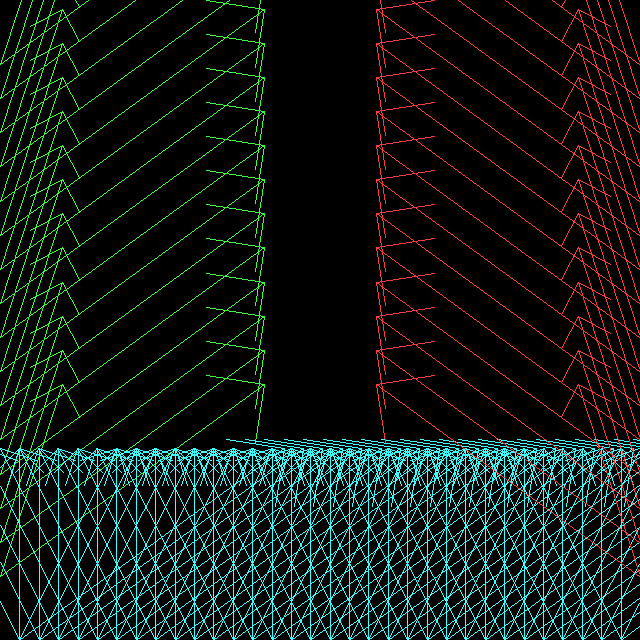


In-process: CLRHeadForSquareImage params = 428,976
per-region counts: left=32  bottom=128  right=32  (expect 32 / 128 / 32)

Generated priors tensor shape: (192, 78)

[P3 result] PASS


In [3]:
from pathlib import Path
from IPython.display import Image, display
png = Path(VERIFY_OUT) / 'priors_square.png'
if png.exists():
    print(f'--- {png.name} ({png.stat().st_size / 1024:.1f} KB) ---')
    display(Image(str(png)))
else:
    print(f'[warn] {png} not produced; check cell 2 log')

# In-process import check (what P4 will do).
TOOLS = 'stage2/rmt_ppad_migration/P3_square_clrhead/tools'
if TOOLS not in sys.path:
    sys.path.insert(0, TOOLS)
from types import SimpleNamespace
from clr_head_square import CLRHeadForSquareImage

cfg = SimpleNamespace(img_w=640, img_h=640, num_classes=2,
                       bg_weight=0.4, ignore_label=255,
                       haskey=lambda k: False)
head = CLRHeadForSquareImage(num_points=72, prior_feat_channels=64,
                              fc_hidden_dim=64, num_priors=192, num_fc=2,
                              refine_layers=3, sample_points=36, cfg=cfg)
n_params = sum(p.numel() for p in head.parameters())
print(f'\nIn-process: CLRHeadForSquareImage params = {n_params:,}')

emb = head.prior_embeddings.weight.detach()
sx = emb[:, 1].numpy()
import numpy as np
print(f'per-region counts: left={int((sx==0).sum())}  '
      f'bottom={int(((sx>0)&(sx<1)).sum())}  '
      f'right={int((sx==1).sum())}  (expect 32 / 128 / 32)')

priors, _ = head.generate_priors_from_embeddings()
assert tuple(priors.shape) == (192, 78), f'unexpected priors shape {priors.shape}'
print(f'\nGenerated priors tensor shape: {tuple(priors.shape)}')
print('\n[P3 result] PASS')